# Занятие 1. Практика: Python в ноутбуке для анализа данных

Этот ноутбук - практическая часть первой лекции курса **«Основы анализа данных и ML для начинающих»**.

Цель занятия: освоиться с Jupyter/Colab и повторить/узнать базовые конструкции Python, которые понадобятся дальше для EDA, подготовки данных и первых моделей.

В этой практике:
- как устроен ноутбук;
- переменные, типы данных, строки;
- списки и циклы;
- множества и словари;
- функции;
- небольшой пример анализа данных без сложных библиотек.



Сегодняшняя практика относится к первому блоку: **работа с данными**. Перед тем как строить модели, нужно уметь хранить данные, преобразовывать их, считать простые статистики и аккуратно оформлять код.


## Минимум по работе с ноутбуком

Ноутбук состоит из ячеек двух основных типов:

- **Markdown** — текст, формулы, пояснения, заголовки;
- **Code** — код Python, который можно запускать.

Полезные действия:

- `Run` / `Shift + Enter` — выполнить текущую ячейку;
- `Kernel -> Restart` — перезапустить Python, если переменные запутались;
- `Run All` — выполнить ноутбук сверху вниз;
- если код зависит от переменной, ячейка с этой переменной должна быть выполнена раньше.


In [8]:
print('Ноутбук работает')


Ноутбук работает


In [9]:
# это комментарий, и его видно только человеку

Для написания коментария, достаточно поставить перед ним решетку, либо использовать шорткат: `ctrl + /`

In [10]:
# если выводить комментарий без знака решетки, то возникнет ошибка

## 1. Переменные и базовые типы данных

Переменная — это имя для значения. В анализе данных переменные часто хранят:

- числа: цена, площадь, количество комнат;
- строки: город, район, описание объявления;
- логические значения: есть ли лифт, является ли объявление новым;
- коллекции: список цен, словарь признаков объекта.


In [11]:
price = 7_500_000
area = 54.3
rooms = 2
city = 'Махачкала'
has_balcony = True

print(price, type(price))
print(area, type(area))
print(city, type(city))
print(has_balcony, type(has_balcony))


7500000 <class 'int'>
54.3 <class 'float'>
Махачкала <class 'str'>
True <class 'bool'>


In [62]:
# Логические значения показывают: условие истинно или ложно
# True  — правда
# False — неправда

price = 7_500_000

is_expensive = price > 7_000_000
is_cheap = price < 5_000_000

print(is_expensive)  # True
print(is_cheap)      # False

True
False


### Арифметика и простые расчёты

На практике почти любой анализ начинается с простых вычислений: цена за квадратный метр, среднее значение, разница между объектами.


In [12]:
price_per_meter = price / area

print(f'Цена объекта: {price:,} руб.')
print(f'Площадь: {area} м²')
print(f'Цена за м²: {price_per_meter:,.0f} руб.')


Цена объекта: 7,500,000 руб.
Площадь: 54.3 м²
Цена за м²: 138,122 руб.


## 2. Строки

Строка (`str`) — последовательность символов. В данных строки встречаются постоянно: названия городов, адреса, описания объявлений, категории.

Со строками важно уметь:

- обращаться к символам и срезам;
- приводить текст к единому виду;
- искать подстроки;
- разбивать строку на части и собирать обратно.


In [ ]:
title = '  2-комнатная квартира, 54 м², 7/10 эт.  '

print(title)
print(title.strip())          # убрать пробелы по краям
print(title.lower())          # привести к нижнему регистру
print(title.replace('м²', 'кв.м'))

# методы можно и комбинировать: title.strip().lower()

  2-комнатная квартира, 54 м², 7/10 эт.  
2-комнатная квартира, 54 м², 7/10 эт.
  2-комнатная квартира, 54 м², 7/10 эт.  
  2-комнатная квартира, 54 кв.м, 7/10 эт.  


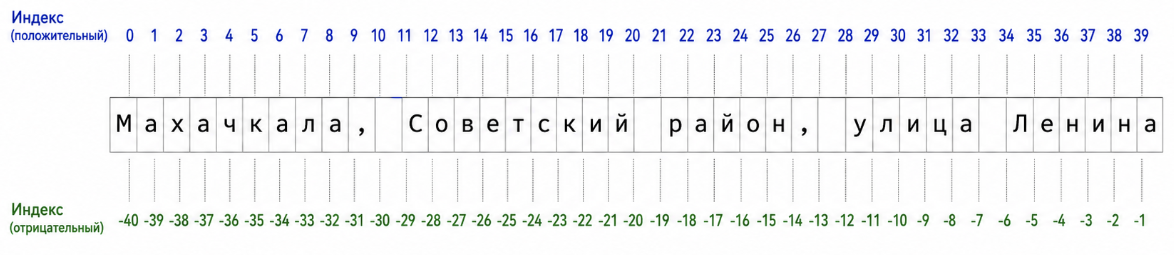


`Важно!`: пробелы и знаки препинания тоже имеют индекс

In [14]:
address = 'Махачкала, Советский район, улица Ленина'

print(address[0])       # первый символ
print(address[:9])      # первые 9 символов
print(address[-6:])     # последние 6 символов
print('район' in address)


М
Махачкала
Ленина
True


In [15]:
parts = address.split(', ')
print(parts)

city = parts[0]
district = parts[1]
street = parts[2]

print(f'Город: {city}')
print(f'Район: {district}')
print(f'Улица: {street}')
print(' | '.join(parts))


['Махачкала', 'Советский район', 'улица Ленина']
Город: Махачкала
Район: Советский район
Улица: улица Ленина
Махачкала | Советский район | улица Ленина


### Небольшая предобработка текста

Перед анализом текст часто приводят к более удобному виду: убирают лишние пробелы, переводят в нижний регистр, удаляют ненужные символы.


In [16]:
description = '  СРОЧНО! Продается квартира, рядом школа, парк и магазины.  '

clean_description = description.strip().lower().replace('!', '').replace(',', '')
words = clean_description.split()

print(clean_description)
print(words)
print(f'Количество слов: {len(words)}')


срочно продается квартира рядом школа парк и магазины.
['срочно', 'продается', 'квартира', 'рядом', 'школа', 'парк', 'и', 'магазины.']
Количество слов: 8


## 3. Списки

Список (`list`) — упорядоченная коллекция значений. В анализе данных список может хранить цены, площади, названия признаков или строки таблицы.

Главное:

- у списка есть порядок и индексы;
- список можно изменять;
- по списку удобно проходить циклом;
- списки часто создают через list comprehension.


In [17]:
prices = [7_500_000, 6_200_000, 8_100_000, 5_900_000, 9_300_000]

print(prices)
print(prices[0])      # первый элемент
print(prices[-1])     # последний элемент
print(prices[:3])     # первые три цены
print(prices[::-1])   # список в обратном порядке


[7500000, 6200000, 8100000, 5900000, 9300000]
7500000
9300000
[7500000, 6200000, 8100000]
[9300000, 5900000, 8100000, 6200000, 7500000]


In [57]:
areas = [54.3, 42.0, 61.5, 38.2, 70.0]

print(f'Количество объектов: {len(prices)}')
print(f'Минимальная цена: {min(prices)}')
print(f'Максимальная цена: {max(prices)}')
print(f'Средняя цена: {sum(prices) / len(prices)}')


Количество объектов: 4
Минимальная цена: 5900000
Максимальная цена: 8100000
Средняя цена: 6925000.0


### Методы списков

Метод изменяет объект или возвращает новое значение. Важно помнить: `append`, `extend`, `sort` меняют список на месте.


In [19]:
prices = [7_500_000, 6_200_000, 8_100_000]

prices.append(5_900_000)
print('После append:', prices)

prices.extend([9_300_000, 6_700_000])
print('После extend:', prices)

prices.sort()
print('После sort:', prices)


После append: [7500000, 6200000, 8100000, 5900000]
После extend: [7500000, 6200000, 8100000, 5900000, 9300000, 6700000]
После sort: [5900000, 6200000, 6700000, 7500000, 8100000, 9300000]


In [20]:
# Копирование важно: иначе две переменные могут ссылаться на один и тот же список
original = [1, 2, 3]
link = original
copy_of_original = original.copy()

original.append(4)

print('original:', original)
print('link:', link)
print('copy:', copy_of_original)


original: [1, 2, 3, 4]
link: [1, 2, 3, 4]
copy: [1, 2, 3]


## 4. Циклы

Цикл нужен, когда одно действие нужно повторить несколько раз: пройти по всем объявлениям, всем ценам, всем словам в тексте.

Чаще всего используется `for`. Если нужен индекс элемента, удобно применять `enumerate`.


In [21]:
prices = [7_500_000, 6_200_000, 8_100_000, 5_900_000]

for price in prices:
    print(f'{price:,} руб.')


7,500,000 руб.
6,200,000 руб.
8,100,000 руб.
5,900,000 руб.


In [22]:
for index, price in enumerate(prices, start=1):
    print(f'Объект {index}: {price:,} руб.')


Объект 1: 7,500,000 руб.
Объект 2: 6,200,000 руб.
Объект 3: 8,100,000 руб.
Объект 4: 5,900,000 руб.


In [63]:
cheap_prices = []
expensive_prices = []

for price in prices:
    if price < 7_000_000:
        cheap_prices.append(price)
    else:
        expensive_prices.append(price)

print('Дешевые квартиры:', cheap_prices)
print('Дорогие квартиры:', expensive_prices)

Дешевые квартиры: [6200000, 5900000]
Дорогие квартиры: [7500000, 8100000]


### List comprehension

List comprehension — компактный способ создать список. Его удобно использовать для простых преобразований и фильтраций.


In [24]:
prices_mln = [price / 1_000_000 for price in prices]
cheap_prices = [price for price in prices if price < 7_000_000]

print(prices_mln)
print(cheap_prices)


[7.5, 6.2, 8.1, 5.9]
[6200000, 5900000]


In [25]:
price_per_meter = [round(price / area) for price, area in zip(prices, areas[:len(prices)])]
print(price_per_meter)


[138122, 147619, 131707, 154450]


## 5. Множества

Множество (`set`) — неупорядоченная коллекция без повторов.

В анализе данных множества полезны, когда нужно:

- быстро убрать дубликаты;
- посмотреть уникальные значения;
- сравнить наборы категорий


In [26]:
cities = ['Махачкала', 'Каспийск', 'Махачкала', 'Дербент', 'Каспийск']
unique_cities = set(cities)

print(cities)
print(unique_cities)
print(f'Уникальных городов: {len(unique_cities)}')


['Махачкала', 'Каспийск', 'Махачкала', 'Дербент', 'Каспийск']
{'Дербент', 'Каспийск', 'Махачкала'}
Уникальных городов: 3


In [27]:
required_columns = {'city', 'price', 'area', 'rooms'}
actual_columns = {'city', 'price', 'area', 'floor'}

print('Не хватает:', required_columns - actual_columns)
print('Лишние/дополнительные:', actual_columns - required_columns)
print('Общие:', required_columns & actual_columns)


Не хватает: {'rooms'}
Лишние/дополнительные: {'floor'}
Общие: {'city', 'area', 'price'}


In [58]:
cities = {'Махачкала', 'Каспийск'}

# add() добавляет один новый элемент
cities.add('Дербент')

print(cities)
# {'Махачкала', 'Каспийск', 'Дербент'}


{'Дербент', 'Каспийск', 'Махачкала'}


In [59]:
# discard() удаляет элемент, если он есть
cities.discard('Каспийск')

print(cities)
# {'Махачкала', 'Дербент'}

{'Дербент', 'Махачкала'}


In [60]:
# Если элемента нет, discard() не выдаст ошибку
cities.discard('Москва')

print(cities)

{'Дербент', 'Махачкала'}


In [61]:
# remove() удаляет элемент, но даст ошибку, если элемента нет
cities.remove('Каспийск')

print(cities)

KeyError: 'Каспийск'

## 6. Словари

Словарь (`dict`) хранит пары `ключ: значение`. Это удобный формат для одного объекта с признаками.

В будущем таблица с данными будет выглядеть как набор строк и столбцов. Пока можно представить одну строку как словарь, а весь датасет — как список словарей.


In [28]:
flat = {
    'city': 'Махачкала',
    'district': 'Советский район',
    'price': 7_500_000,
    'area': 54.3,
    'rooms': 2,
    'floor': 7,
}

print(flat)
print(flat['price'])
print(flat.get('metro', 'нет данных'))


{'city': 'Махачкала', 'district': 'Советский район', 'price': 7500000, 'area': 54.3, 'rooms': 2, 'floor': 7}
7500000
нет данных


In [29]:
for key, value in flat.items():
    print(f'{key}: {value}')


city: Махачкала
district: Советский район
price: 7500000
area: 54.3
rooms: 2
floor: 7


In [30]:
listings = [
    {'city': 'Махачкала', 'price': 7_500_000, 'area': 54.3, 'rooms': 2},
    {'city': 'Каспийск', 'price': 6_200_000, 'area': 42.0, 'rooms': 1},
    {'city': 'Махачкала', 'price': 8_100_000, 'area': 61.5, 'rooms': 3},
    {'city': 'Дербент', 'price': 5_900_000, 'area': 38.2, 'rooms': 1},
    {'city': 'Каспийск', 'price': 9_300_000, 'area': 70.0, 'rooms': 3},
]

for listing in listings:
    price_m2 = listing['price'] / listing['area']
    print(listing['city'], listing['rooms'], f'{price_m2:,.0f} руб./м²')


Махачкала 2 138,122 руб./м²
Каспийск 1 147,619 руб./м²
Махачкала 3 131,707 руб./м²
Дербент 1 154,450 руб./м²
Каспийск 3 132,857 руб./м²


In [ ]:
# выведем 3 по счету объявление
listings[2]

# получили словарь, так как список состоял из словарей

{'city': 'Махачкала', 'price': 8100000, 'area': 61.5, 'rooms': 3}

In [49]:
# далее выведем город
listings[2]['city']


'Махачкала'

In [51]:
# и выведем площадь
listings[2]['area']


61.5

In [53]:
# округлим для удобства
round(listings[2]['area'])

62

## 7. Функции

Функция — именованный блок кода. Она помогает не копировать одно и то же действие много раз

Функция обычно:

- получает аргументы;
- выполняет расчёт или преобразование;
- возвращает результат через `return`


In [32]:
def price_per_square_meter(price, area):
    return price / area

result = price_per_square_meter(7_500_000, 54.3)
print(f'{result:,.0f} руб./м²')


138,122 руб./м²


In [33]:
def describe_listing(city, price, area, rooms=1):
    price_m2 = price_per_square_meter(price, area)
    return f'{city}: {rooms}-комн., {area} м², {price_m2:,.0f} руб./м²'

print(describe_listing('Махачкала', 7_500_000, 54.3, rooms=2))
print(describe_listing('Каспийск', 6_200_000, 42.0))


Махачкала: 2-комн., 54.3 м², 138,122 руб./м²
Каспийск: 1-комн., 42.0 м², 147,619 руб./м²


In [34]:
def is_valid_listing(listing):
    required_fields = {'city', 'price', 'area', 'rooms'}
    if set(listing) != required_fields:
        return False
    if listing['price'] <= 0 or listing['area'] <= 0:
        return False
    if listing['rooms'] <= 0:
        return False
    return True

for listing in listings:
    print(listing, is_valid_listing(listing))


{'city': 'Махачкала', 'price': 7500000, 'area': 54.3, 'rooms': 2} True
{'city': 'Каспийск', 'price': 6200000, 'area': 42.0, 'rooms': 1} True
{'city': 'Махачкала', 'price': 8100000, 'area': 61.5, 'rooms': 3} True
{'city': 'Дербент', 'price': 5900000, 'area': 38.2, 'rooms': 1} True
{'city': 'Каспийск', 'price': 9300000, 'area': 70.0, 'rooms': 3} True


### Функция для предобработки текста

Это пример маленькой функции, похожей на то, что часто встречается в реальных проектах: привести текст к единому виду перед дальнейшим анализом.


In [35]:
def preprocess_text(text):
    text = text.strip().lower()
    for symbol in [',', '.', '!', '?', ':', ';']:
        text = text.replace(symbol, '')
    return text.split()

text = 'Светлая квартира, рядом школа, парк и магазины!'
print(preprocess_text(text))


['светлая', 'квартира', 'рядом', 'школа', 'парк', 'и', 'магазины']


## 8. Мини-практика: простой анализ списка объявлений

Задача: по небольшому списку объявлений посчитать базовые показатели:

- цену за квадратный метр для каждого объекта;
- среднюю цену по всем объектам;
- среднюю цену за м² по городам;
- список объектов дешевле заданного порога.


In [36]:
def add_price_per_meter(listing):
    listing = listing.copy()
    listing['price_per_meter'] = round(listing['price'] / listing['area'])
    return listing

prepared_listings = [add_price_per_meter(listing) for listing in listings]
prepared_listings


[{'city': 'Махачкала',
  'price': 7500000,
  'area': 54.3,
  'rooms': 2,
  'price_per_meter': 138122},
 {'city': 'Каспийск',
  'price': 6200000,
  'area': 42.0,
  'rooms': 1,
  'price_per_meter': 147619},
 {'city': 'Махачкала',
  'price': 8100000,
  'area': 61.5,
  'rooms': 3,
  'price_per_meter': 131707},
 {'city': 'Дербент',
  'price': 5900000,
  'area': 38.2,
  'rooms': 1,
  'price_per_meter': 154450},
 {'city': 'Каспийск',
  'price': 9300000,
  'area': 70.0,
  'rooms': 3,
  'price_per_meter': 132857}]

In [37]:
average_price = sum(listing['price'] for listing in prepared_listings) / len(prepared_listings)
print(f'Средняя цена: {average_price:,.0f} руб.')


Средняя цена: 7,400,000 руб.


In [38]:
city_to_prices = {}

for listing in prepared_listings:
    city = listing['city']
    if city not in city_to_prices:
        city_to_prices[city] = []
    city_to_prices[city].append(listing['price_per_meter'])

for city, values in city_to_prices.items():
    avg_value = sum(values) / len(values)
    print(f'{city}: {avg_value:,.0f} руб./м²')


Махачкала: 134,914 руб./м²
Каспийск: 140,238 руб./м²
Дербент: 154,450 руб./м²


In [39]:
def filter_by_budget(listings, max_price):
    return [listing for listing in listings if listing['price'] <= max_price]

budget_options = filter_by_budget(prepared_listings, max_price=7_000_000)
budget_options


[{'city': 'Каспийск',
  'price': 6200000,
  'area': 42.0,
  'rooms': 1,
  'price_per_meter': 147619},
 {'city': 'Дербент',
  'price': 5900000,
  'area': 38.2,
  'rooms': 1,
  'price_per_meter': 154450}]

## 9. Быстрый взгляд на таблицу

Дальше на курсе мы будем работать с таблицами через `pandas`. Сейчас достаточно увидеть идею: список словарей можно превратить в таблицу и быстро посмотреть на данные.


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# cделаем из словаря датафрейм!
flat_df = pd.DataFrame(prepared_listings)
print(flat_df)

        city    price  area  rooms  price_per_meter
0  Махачкала  7500000  54.3      2           138122
1   Каспийск  6200000  42.0      1           147619
2  Махачкала  8100000  61.5      3           131707
3    Дербент  5900000  38.2      1           154450
4   Каспийск  9300000  70.0      3           132857


In [42]:
display(flat_df)

,city,price,area,rooms,price_per_meter
0,Махачкала,7500000,54.3,2,138122
1,Каспийск,6200000,42.0,1,147619
2,Махачкала,8100000,61.5,3,131707
3,Дербент,5900000,38.2,1,154450
4,Каспийск,9300000,70.0,3,132857


In [43]:
flat_df

,city,price,area,rooms,price_per_meter
0,Махачкала,7500000,54.3,2,138122
1,Каспийск,6200000,42.0,1,147619
2,Махачкала,8100000,61.5,3,131707
3,Дербент,5900000,38.2,1,154450
4,Каспийск,9300000,70.0,3,132857


In [ ]:
flat_df.groupby('city')[['price', 'price_per_meter']].mean().round(0)

# о группировке подробнее поговорим в следующий раз

,price,price_per_meter
city,,
Дербент,5900000.0,154450.0
Каспийск,7750000.0,140238.0
Махачкала,7800000.0,134914.0


## 10. Пара простых графиков

Графики помогают быстрее увидеть различия и связи в данных. Начнём с самых простых вариантов: столбчатой диаграммы и диаграммы рассеяния.


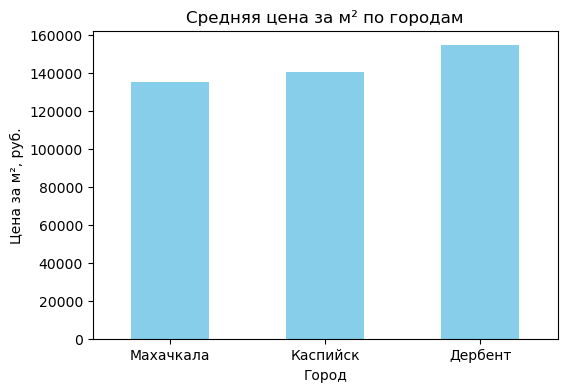

In [45]:
avg_price_per_meter = flat_df.groupby('city')['price_per_meter'].mean().sort_values()

avg_price_per_meter.plot(kind='bar', color='skyblue', figsize=(6, 4))
plt.title('Средняя цена за м² по городам')
plt.xlabel('Город')
plt.ylabel('Цена за м², руб.')
plt.xticks(rotation=0)
plt.show()


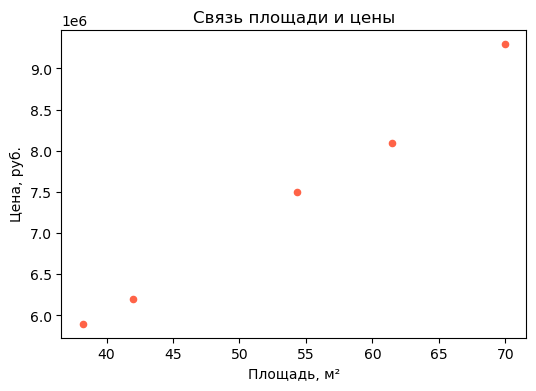

In [46]:
flat_df.plot(kind='scatter', x='area', y='price', figsize=(6, 4), color='tomato')
plt.title('Связь площади и цены')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, руб.')
plt.show()


`Можно ли использовать ИИ?`: ИИ использовать при решении дз *допустимо*, однако важно использовать инструмент как помощника для объяснения. **Ни в коем случае не копипастите решение полностью, ведь так вы ничему не научитесь.**

[Ссылка на дз #1](https://stepik.org/course/297193/edit)